Loading weights:   0%|          | 0/341 [00:00<?, ?it/s]

Input shape: torch.Size([1, 7])
Input tokens: ['<bos>', 'Albert', ' Einstein', ' developed', ' the', ' theory', ' of']
Number of model layers: 25
Hidden states for first layer: torch.Size([1, 7, 2048])
Layer 0: ['-', '-', ' F', '-', ' S', '-', ' "']
Layer 1: ['ed', 'etta', 'Â´', ' methods', ' same', ' of', ' sorts']
Layer 2: ['import', ' peeled', 'ian', ' strong', ' same', ' of', ' sorts']
Layer 3: ['import', ' peeled', 'ian', ' strong', ' same', ' of', ' sorts']
Layer 4: [' realise', ' peeled', ' Jr', ' strong', ' same', ' of', ' underlying']
Layer 5: [' realise', 'import', ' Jr', ' an', ' most', ' of', ' underlying']
Layer 6: [' realise', 'import', ' Jr', ' an', ' most', ' of', ' sorts']
Layer 7: [' realise', 'import', 'âĢ', ' quite', ' most', ' of', ' "']
Layer 8: ['iveness', 'import', ' Jr', ' plans', ' most', ' of', " '"]
Layer 9: ['iveness', 'import', ' Jr', ' an', ' most', ' of', " '"]
Layer 10: ['iveness', 'import', 'âĢ', ' an', ' most', ' of', " '"]
Layer 11: ['iveness', 'impo

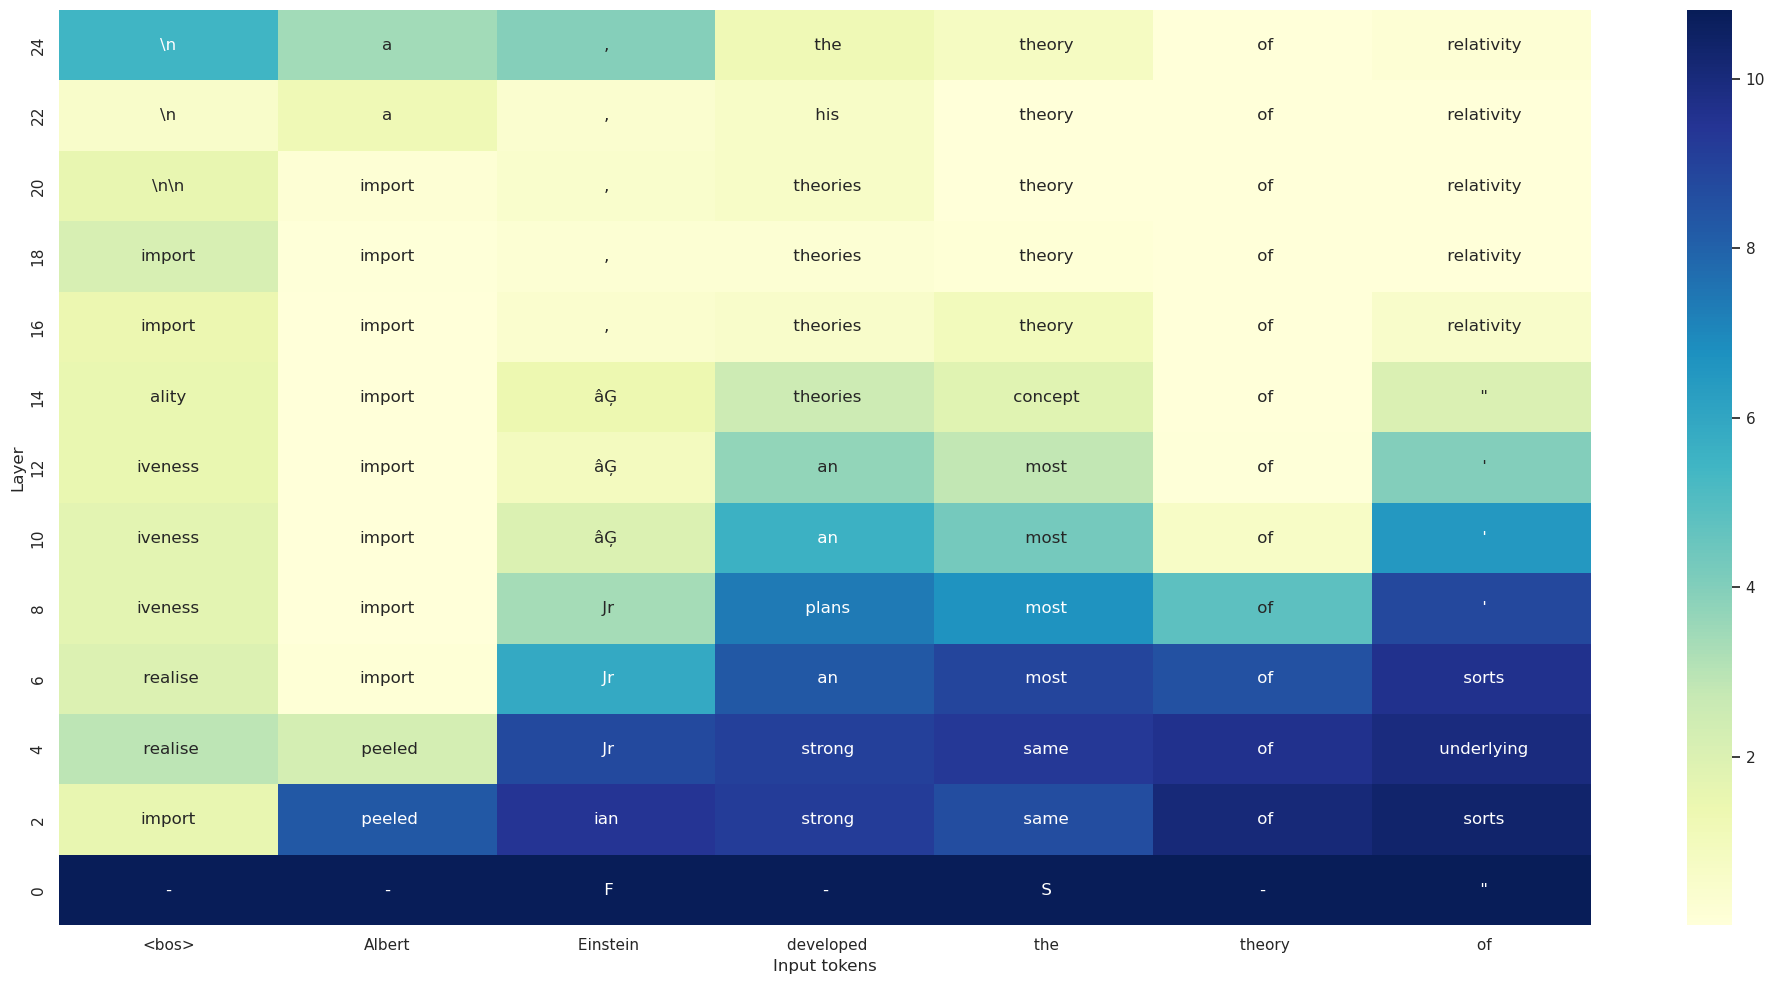

In [9]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- helper to strip the annoying Ġ / Ċ tokenizer artifacts ----
def cleanup_tokens(tokens):
    def _clean(t):
        return t.replace("Ġ", " ").replace("Ċ", "\\n")

    if len(tokens) > 0 and isinstance(tokens[0], list):
        return [[_clean(t) for t in row] for row in tokens]

    return [_clean(t) for t in tokens]


# ---- load model ----
model_id = "microsoft/phi-1.5"
#model_id = "Qwen/Qwen3-4B"


model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
).eval().to(device)

tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    add_bos_token=True,
    bos_token="<bos>",
    use_fast=False,
)


# ---- tokenize input ----
#example = "The capital of France is"
example = "Albert Einstein developed the theory of"

inputs = tokenizer(example, return_tensors="pt").to(device)
print("Input shape:", inputs["input_ids"].shape)

original_input_tokens = tokenizer.convert_ids_to_tokens(
    inputs["input_ids"][0],
    skip_special_tokens=False,
)
original_input_tokens = cleanup_tokens(original_input_tokens)

print("Input tokens:", original_input_tokens)


# ---- forward pass with hidden states ----
with torch.no_grad():
    outputs = model(
        **inputs,
        output_hidden_states=True,
    )

hidden_states = outputs.hidden_states

print("Number of model layers:", len(hidden_states))
print("Hidden states for first layer:", hidden_states[0].shape)


# ---- entropy helper ----
def entropy_from_logits(logits):
    probs = torch.nn.functional.softmax(logits, dim=-1).clamp(1e-8, 1)
    return -torch.sum(probs * torch.log(probs), dim=-1).squeeze()


# ---- logit lens: apply lm_head to each layer's hidden state ----
logitlens = []
entropies = []

for i, hidden_state in enumerate(hidden_states):
    logits = model.lm_head(hidden_state)

    entropy = (
        entropy_from_logits(logits)
        .float()
        .cpu()
        .detach()
        .numpy()
    )

    predicted_token_ids = logits.argmax(dim=-1)

    predicted_tokens = tokenizer.convert_ids_to_tokens(
        predicted_token_ids[0],
        skip_special_tokens=False,
    )
    predicted_tokens = cleanup_tokens(predicted_tokens)

    logitlens.append(predicted_tokens)
    entropies.append(entropy)

    print(f"Layer {i}: {predicted_tokens}")


# ---- heatmap colored by entropy ----
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(20, 10))

sns.heatmap(
    np.stack(entropies)[::2],
    annot=np.array(logitlens)[::2],
    fmt="",
    cmap="YlGnBu",
    xticklabels=original_input_tokens,
    yticklabels=list(range(len(logitlens)))[::2],
    ax=ax,
)

ax.invert_yaxis()
ax.set_xlabel("Input tokens")
ax.set_ylabel("Layer")

fig.tight_layout()

# Export the figure as a high-resolution PNG.
output_path = "logit_lens_heatmap.png"
fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

print(f"Saved heatmap to: {output_path}")

plt.show()